# Palindrome RNN Accuracy Study

This notebook addresses Part III Task 2: train the Vanilla RNN from Task 1 across different palindrome lengths and plot how the accuracy changes with the sequence length.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from argparse import Namespace

from dataset import PalindromeDataset
from train import train as train_rnn


## Training helpers

Utility functions for training the Vanilla RNN at a chosen palindrome length and measuring its accuracy.


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

In [3]:
def build_config(seq_length, train_steps, batch_size, hidden_dim, learning_rate, max_norm=10.0, log_interval=20):
    return Namespace(
        input_length=seq_length,
        input_dim=1,
        num_classes=10,
        num_hidden=hidden_dim,
        batch_size=batch_size,
        learning_rate=learning_rate,
        train_steps=train_steps,
        max_norm=max_norm,
        log_interval=log_interval,
    )


def train_model_for_length(
    seq_length,
    train_steps=500,
    batch_size=128,
    hidden_dim=128,
    learning_rate=1e-3,
    max_norm=10.0,
    log_interval=10,
):
    config = build_config(seq_length, train_steps, batch_size, hidden_dim, learning_rate, max_norm, log_interval)
    model, _, final_accuracy = train_rnn(config)
    return model, final_accuracy


def evaluate_accuracy(model, seq_length, num_batches=50, batch_size=256):
    dataset = PalindromeDataset(seq_length + 1)
    loader = DataLoader(dataset, batch_size=batch_size, num_workers=1)

    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for step, (inputs, targets) in enumerate(loader):
            inputs = inputs.to(device=device, dtype=torch.float32).unsqueeze(-1)
            targets = targets.to(device=device, dtype=torch.long)

            logits = model(inputs)
            predictions = torch.argmax(logits, dim=1)
            total_correct += (predictions == targets).sum().item()
            total_examples += targets.numel()

            if step >= num_batches:
                break

    return total_correct / total_examples


## Accuracy sweep over palindrome length

Train a fresh RNN for each palindrome length and record its validation accuracy.


In [4]:
lengths = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
train_steps = 500
log_interval = 20

results = []
for seq_len in lengths:
    print(f"\n=== Training sequence length {seq_len} ===")
    model, last_train_acc = train_model_for_length(
        seq_len,
        train_steps=train_steps,
        log_interval=log_interval,
    )
    eval_acc = evaluate_accuracy(model, seq_len)
    results.append({
        "length": seq_len,
        "train_acc": last_train_acc,
        "eval_acc": eval_acc,
    })

results



=== Training sequence length 5 ===
Step 00000 | Loss 2.5409 | Accuracy 0.1094
Step 00020 | Loss 1.5649 | Accuracy 0.4375
Step 00040 | Loss 1.4666 | Accuracy 0.4219
Step 00060 | Loss 1.0913 | Accuracy 0.6016
Step 00080 | Loss 1.1580 | Accuracy 0.4922
Step 00100 | Loss 0.8925 | Accuracy 0.6328
Step 00120 | Loss 0.7848 | Accuracy 0.7188
Step 00140 | Loss 0.8607 | Accuracy 0.5469
Step 00160 | Loss 0.8879 | Accuracy 0.5156
Step 00180 | Loss 0.6923 | Accuracy 0.6094
Step 00200 | Loss 0.6003 | Accuracy 0.7031
Step 00220 | Loss 0.4236 | Accuracy 0.8047
Step 00240 | Loss 0.5315 | Accuracy 0.6797
Step 00260 | Loss 0.2865 | Accuracy 1.0000
Step 00280 | Loss 0.5084 | Accuracy 0.6797
Step 00300 | Loss 0.3890 | Accuracy 0.7891
Step 00320 | Loss 0.2515 | Accuracy 0.9922
Step 00340 | Loss 0.3641 | Accuracy 0.8359
Step 00360 | Loss 0.2576 | Accuracy 0.8516
Step 00380 | Loss 0.3006 | Accuracy 0.8516
Step 00400 | Loss 0.1466 | Accuracy 1.0000
Step 00420 | Loss 0.1804 | Accuracy 1.0000
Step 00440 | Loss 

[{'length': 5, 'train_acc': 0.9140625, 'eval_acc': 0.9944087009803921},
 {'length': 10, 'train_acc': 0.8984375, 'eval_acc': 0.8720128676470589},
 {'length': 15, 'train_acc': 0.8671875, 'eval_acc': 0.8671109068627451},
 {'length': 20, 'train_acc': 0.3046875, 'eval_acc': 0.4739583333333333},
 {'length': 25, 'train_acc': 0.0625, 'eval_acc': 0.0978860294117647},
 {'length': 30, 'train_acc': 0.078125, 'eval_acc': 0.09719669117647059},
 {'length': 35, 'train_acc': 0.0859375, 'eval_acc': 0.10033700980392157},
 {'length': 40, 'train_acc': 0.078125, 'eval_acc': 0.09934129901960784},
 {'length': 45, 'train_acc': 0.0546875, 'eval_acc': 0.10340073529411764},
 {'length': 50, 'train_acc': 0.109375, 'eval_acc': 0.10294117647058823}]

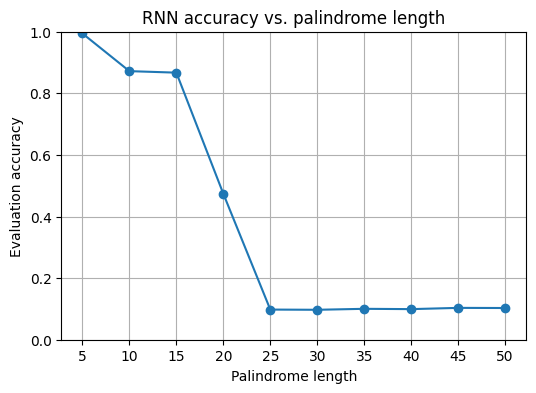

In [5]:
lengths = [entry["length"] for entry in results]
accuracies = [entry["eval_acc"] for entry in results]

plt.figure(figsize=(6, 4))
plt.plot(lengths, accuracies, marker='o')
plt.ylim(0, 1)
plt.xlabel('Palindrome length')
plt.ylabel('Evaluation accuracy')
plt.title('RNN accuracy vs. palindrome length')
plt.xticks(range(min(lengths), max(lengths) + 1, 5))
plt.grid(True)
plt.show()
